<a href="https://colab.research.google.com/github/Gabi-galv/Data-science-I/blob/main/Entrega1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#0. Abstract:

Según la Organización Mundial de la Salud (OMS), el suicidio es definido como el acto
deliberado de acabar con la propia vida. Se reconoce que el suicidio es un problema
grave de salud pública que afecta a individuos, comunidades y sociedades en todo el
mundo. Este estudio se realizó en el marco de una investigación en Argentina entre el año 2017 y 2023, años atravesados por la pandemia de COVID-19, suceso que se caracterizó por profundizar padecimientos en la salud mental de las personas.
El objetivo de este estudio es determinar si la pandemia COVID-19 influyó en la tasa de suicidios en el pais. La hipótesis planteada en el presente estudio es que el año 2020 (inicio pandemia) registró el mayor número de casos denunciados.
Los datos utilizados para realizar este estudio se obtuvieron de la base de datos del Sistema de Alerta Temprana (SAT) del Sistema Nacional de Información Criminal (SNIC).
Se tomó para responder la hipótesis el total de casos registrados, segmentándolos por año y realizando un gráfico adecuado que permita comparar fácil y velózmente cómo fue la evolución de los registros a lo largo del tiempo (gráfico de barras).
Los resultados mostraron que contrario a la lógica de las consecuencias que podría haber generado el encierro de la cuarentena y el poco o nulo contacto social, sorprendentemente el año 2020 fue el que registró menos casos en el período estudiado.
Se evidencia que el pico de casos se generó 2 años después, por lo que no se puede descartar que la pandemia no haya generado un impacto tardío en la salud mental de los argentinos, sumado a otros factores que también influyen en este indicador.


#1. Configuración del entorno

In [ ]:
# Importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

#2. Carga del dataset

In [ ]:
df = pd.read_csv( ' https://raw.githubusercontent.com/Gabi-galv/Data-science-I/refs/heads/main/SAT-SS-BU_2017-2023.csv ', sep=";")

In [ ]:
# Exploración de los datos

print('Primeras 5 filas del DataSet')
df.head()

Primeras 5 filas del DataSet


,id_hecho,tipo_persona_id,federal,provincia_id,provincia_nombre,departamento_id,departamento_nombre,localidad_id,localidad_nombre,anio,...,modalidad_ampliado,modalidad_otro,motivo_origen_registro,motivo_origen_registro_otro,suicida_sexo,suicida_tr_edad,suicida_18_años_o_mas,suicida_clase,suicida_clase_otro,suicida_identidad_genero
0,8529,Suicida idRegistro 20712,No,42,La Pampa,42002,Norte (General Pico),105030,General Pico,2017,...,Ahorcamiento,NaN,Intervención policial,NaN,Masculino,20-24,Si,Sin determinación,NaN,Sin determinar
1,8530,Suicida idRegistro 20713,No,42,La Pampa,42003,Sur (General Acha),70030,Guatraché,2017,...,Arma de fuego,NaN,Intervención policial,NaN,Masculino,55-59,Si,Sin determinación,NaN,Sin determinar
2,8569,Suicida idRegistro 20752,No,78,Santa Cruz,78021,Güer Aike,60,28 de Noviembre,2017,...,Ahorcamiento,NaN,Denuncia particular,NaN,Masculino,15-19,No,Sin determinación,NaN,Sin determinar
3,8705,Suicida idRegistro 20894,No,58,Neuquén,58035,Confluencia,70,Neuquén,2017,...,Arma de fuego,NaN,Intervención policial,NaN,Masculino,20-24,Si,Sin determinación,NaN,Sin determinar
4,8706,Suicida idRegistro 20895,No,58,Neuquén,58035,Confluencia,100,Plottier,2017,...,Ahorcamiento,NaN,Intervención policial,NaN,Masculino,20-24,Si,Sin determinación,NaN,Sin determinar


In [ ]:
#Info del dataframe

print('Información del DataSet')
df.info()

Información del DataSet
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25920 entries, 0 to 25919
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   id_hecho                     25920 non-null  int64 
 1   tipo_persona_id              25920 non-null  object
 2   federal                      25920 non-null  object
 3   provincia_id                 25920 non-null  int64 
 4   provincia_nombre             25920 non-null  object
 5   departamento_id              25920 non-null  int64 
 6   departamento_nombre          25920 non-null  object
 7   localidad_id                 25920 non-null  object
 8   localidad_nombre             25920 non-null  object
 9   anio                         25920 non-null  int64 
 10  mes                          25920 non-null  int64 
 11  fecha_hecho                  25920 non-null  object
 12  hora_hecho                   25920 non-null  object
 13  tipo_lu

In [ ]:
#cambio tipo de dato de "fecha_hecho" y "hora_hecho"
df['fecha_hecho'] = pd.to_datetime(df['fecha_hecho'], format='%d/%m/%Y', errors='coerce')
df['hora_hecho'] = pd.to_datetime(df['hora_hecho'], format='%H:%M', errors='coerce').dt.time

#3. Exploración del DataSet

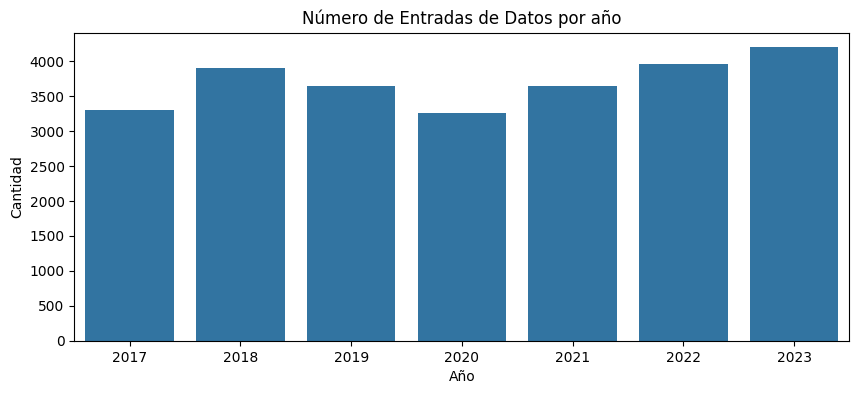

In [ ]:
# Cantidad de registros por año

plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='anio')
plt.title('Número de Entradas de Datos por año')
plt.xlabel('Año')
plt.ylabel('Cantidad')
plt.show()

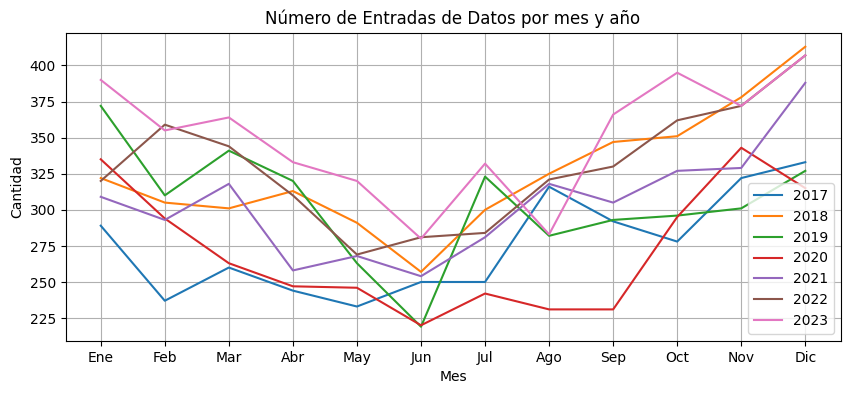

In [ ]:
# Gráfico de líneas por mes y año

ConteoPorMes = df.groupby(['anio', 'mes']).size().unstack(level=0)

plt.figure(figsize=(10, 4))
for anio in ConteoPorMes.columns:
    plt.plot(ConteoPorMes.index, ConteoPorMes[anio], label=str(anio))

plt.title('Número de Entradas de Datos por mes y año')
plt.xlabel('Mes')
plt.ylabel('Cantidad')
plt.legend()
plt.xticks(np.arange(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.grid(True)
plt.show()

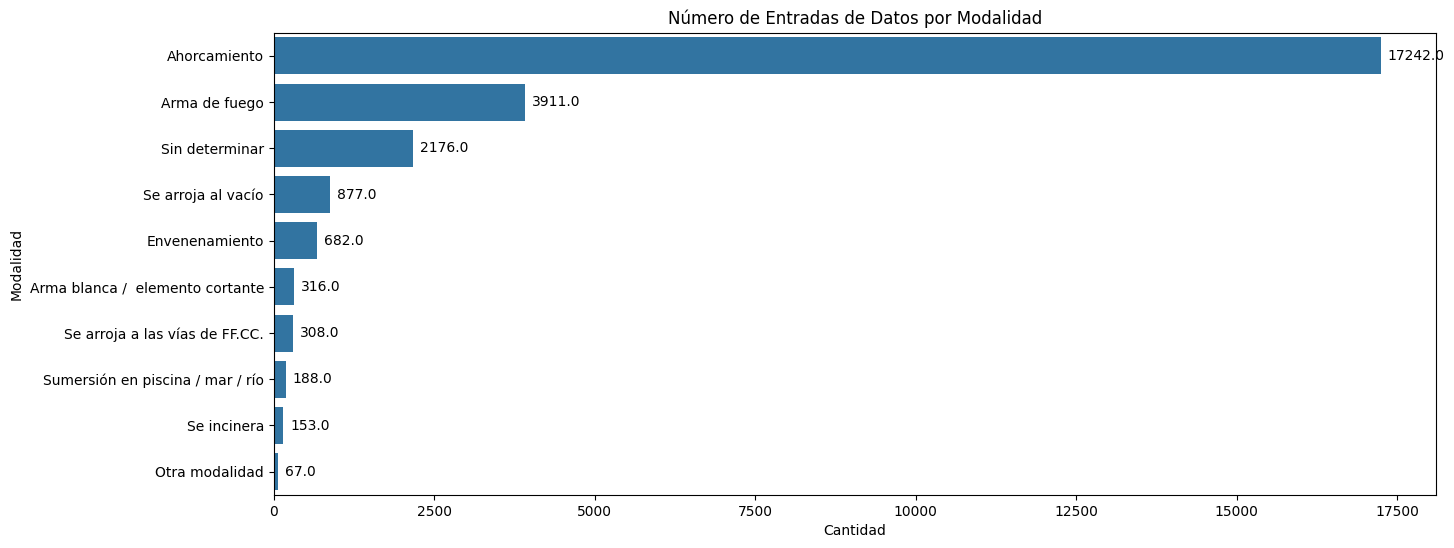

In [ ]:
# Cantidad de registros por modalidad

plt.figure(figsize=(15, 6))
ax = sns.countplot(data=df, y='modalidad', order = df['modalidad'].value_counts().index)
plt.title('Número de Entradas de Datos por Modalidad')
plt.xlabel('Cantidad')
plt.ylabel('Modalidad')

# Etiquetas
for p in ax.patches:
    ax.annotate(f'{p.get_width()}', (p.get_width(), p.get_y() + p.get_height()/2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.show()

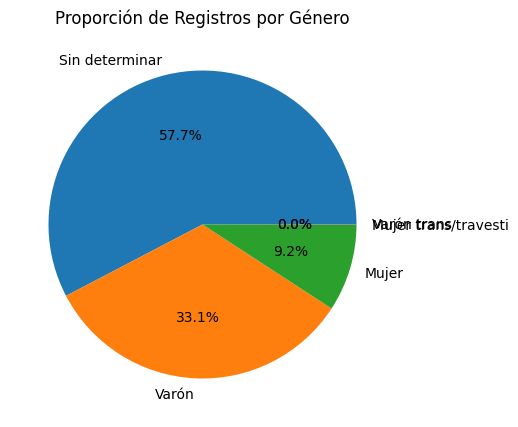

In [ ]:
# Comparativa registros por id género

plt.figure(figsize=(5,5))
plt.pie(df['suicida_identidad_genero'].value_counts(), labels=df['suicida_identidad_genero'].value_counts().index, autopct='%1.1f%%')
plt.title('Proporción de Registros por Género')
plt.show()